In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression



# Load the CSV files
mouth_data = pd.read_csv('../data/mouth.csv')
df = pd.read_csv('../data/no_mouth_neurons_full.csv')

print(mouth_data.head())
print(df.head())

mouth_x = mouth_data['x'].values[0]
mouth_y = mouth_data['y'].values[0]

df['x_norm'] = df.x - mouth_x
df['y_norm'] = df.y - mouth_y



df_0 = df.loc[df.groupby('track_id')['t'].idxmin()][['track_id', 't', 'x_norm', 'y_norm']]




df['r'] = np.sqrt(df.x_norm**2 + df.y_norm**2)
df_0['r'] = np.sqrt(df_0.x_norm**2 + df_0.y_norm**2)
df['theta'] = np.arctan2(df.y_norm, df.x_norm)
df_0['theta'] = np.arctan2(df_0.y_norm, df_0.x_norm)


   track_id    t            y            x
0       0.0  0.0  2114.177155  2228.966627
   track_id   t            y            x
0         0  33  3404.921103  3605.590113
1         0  34  3401.000000  3608.000000
2         0  35  3401.000000  3609.000000
3         0  36  3401.000000  3610.000000
4         0  37  3400.000000  3610.000000


Text(0, 0.5, 'Count')

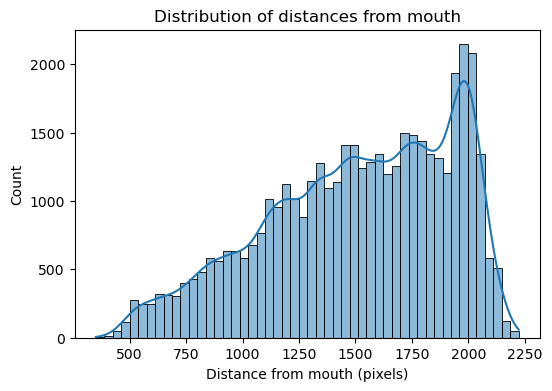

In [2]:
plt.figure(figsize=(6,4))
sns.histplot(df.r, bins = 50, kde = True)
plt.title('Distribution of distances from mouth')
plt.xlabel('Distance from mouth (pixels)')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

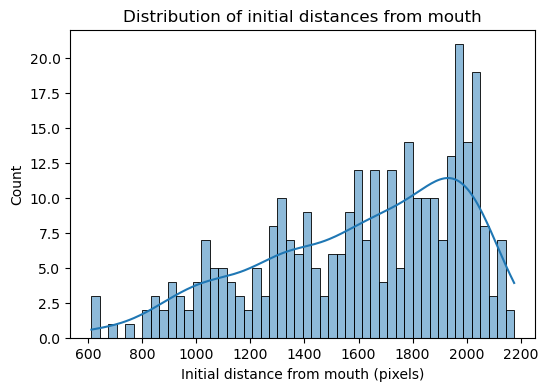

In [3]:
plt.figure(figsize=(6,4))
sns.histplot(df_0.r, bins = 50, kde = True)
plt.title('Distribution of initial distances from mouth')
plt.xlabel('Initial distance from mouth (pixels)')
plt.ylabel('Count')

In [8]:
counts, bin_edges = np.histogram(df_0.r, bins=50)
midpoints = 0.5 * (bin_edges[1:] + bin_edges[:-1])

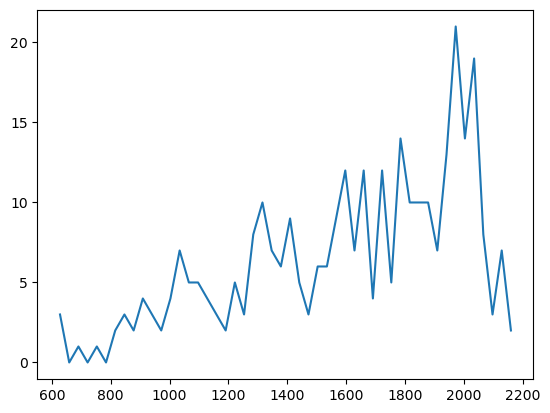

In [9]:
plt.plot(midpoints, counts)

In [14]:
model = LinearRegression()
X = midpoints.reshape(-1, 1)
y = counts
model.fit(X, y)
slope = model.coef_[0]
intercept = model.intercept_
print(f'Linear Regression: slope = {slope}, intercept = {intercept}')

Linear Regression: slope = 0.006906657430081604, intercept = -3.267050983098959


In [22]:
slope_no_bias = np.mean(counts/midpoints)
print(f'Mean slope without bias term: {slope_no_bias}')

Mean slope without bias term: 0.004217402996460697


Text(0.5, 1.0, 'Histogram of Initial Distances with Linear Fit')

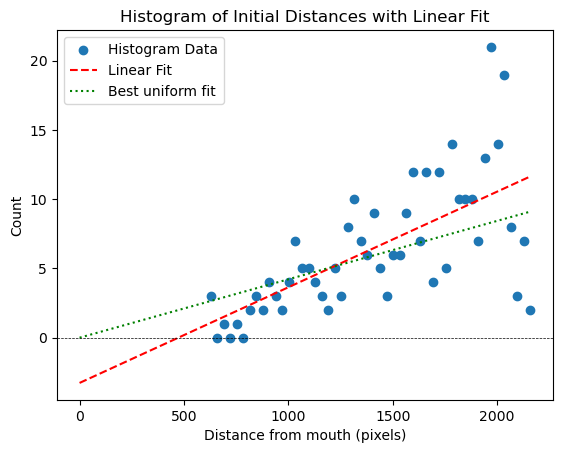

In [26]:
preds = model.predict(np.linspace(0, midpoints.max(), 100).reshape(-1, 1))
plt.scatter(midpoints, counts, label='Histogram Data')
plt.plot(np.linspace(0, midpoints.max(), 100), preds, color='red', linestyle='--', label='Linear Fit')
plt.plot(np.linspace(0, midpoints.max(), 100), slope_no_bias * np.linspace(0, midpoints.max(), 100), color='green', linestyle=':', label='Best uniform fit')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.xlabel('Distance from mouth (pixels)')
plt.ylabel('Count')
plt.title('Histogram of Initial Distances with Linear Fit')

In [27]:
min_dist = df_0.r.min()
max_dist = df_0.r.max()

norm_factor = (slope/2) * (max_dist**2 - min_dist**2) + intercept * (max_dist - min_dist)
print(f'Normalization factor: {norm_factor}')

Normalization factor: 9944.744860116782


In [36]:
def sample_from_distribution(n_samples, slope, intercept, min_dist, max_dist):
    """
    Sample from the distribution p(r) = (slope * r + intercept) / norm_factor
    using inverse transform sampling.
    """
    # Generate uniform random samples
    u = np.random.uniform(0, 1, n_samples)
    
    # Inverse CDF: solve for r given u
    # CDF(r) = integral of p(r) from min_dist to r
    # For linear p(r) = (slope*r + intercept)/norm_factor:
    # CDF(r) = (slope/2 * (r^2 - min_dist^2) + intercept * (r - min_dist)) / norm_factor
    
    # Setting CDF(r) = u and solving the quadratic equation:
    # (slope/2) * r^2 + intercept * r - (slope/2 * min_dist^2 + intercept * min_dist + u * norm_factor) = 0
    
    #normalizing factor: 
    norm_factor = (slope/2) * (max_dist**2 - min_dist**2) + intercept * (max_dist - min_dist)


    a = slope / 2
    b = intercept
    c = -(slope / 2 * min_dist**2 + intercept * min_dist + u * norm_factor)
    
    # Quadratic formula: r = (-b ± sqrt(b^2 - 4ac)) / 2a
    discriminant = b**2 - 4*a*c
    r_samples = (-b + np.sqrt(discriminant)) / (2*a)
    
    return r_samples

# Test: generate samples
samples = sample_from_distribution(10000,  slope, intercept, min_dist, max_dist)

Text(0.5, 1.0, 'Samples from fitted distribution')

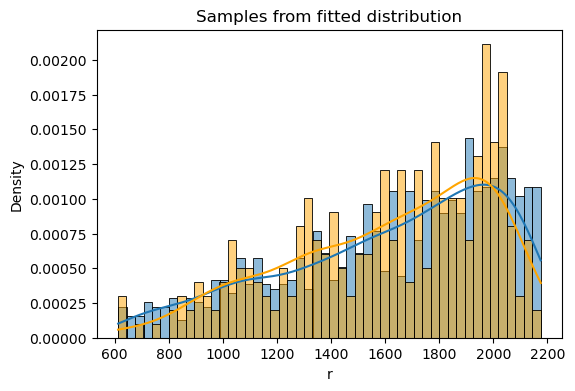

In [37]:
samples = sample_from_distribution(1000,  slope, intercept, min_dist, max_dist)
plt.figure(figsize=(6,4))
sns.histplot(samples, bins=50, kde=True,stat = 'density') 
sns.histplot(df_0.r, bins=50, kde=True, stat='density', color='orange', alpha=0.5)
plt.title('Samples from fitted distribution')